# Topic Modeling of Thai Constitutions

This notebook performs topic modeling on the preprocessed Thai constitution data using Latent Dirichlet Allocation (LDA). We use TF-IDF and Bigrams for better thematic separation, with a focus on removing structural noise (numbers and legal markers).

In [95]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 1. Setup Thai Font
font_path = '../../static/font/LINESeedSansTH_Rg.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 2. Comprehensive Custom Stop Words
custom_stop_words = [
    # Numbers (Strings and Digits)
    '1', '2', '3', '4', '5', '6', '7', '8', '9', '0',
    'หนึ่ง', 'สอง', 'สาม', 'สี่', 'ห้า', 'หก', 'เจ็ด', 'แปด', 'เก้า', 'สิบ', 'ศูนย์',
    'ที่หนึ่ง', 'ที่สอง', 'ที่สาม', 'ที่สี่', 'ที่ห้า', 'ลำดับ', 
    
    # Structural Legal Markers
    'บท', 'ข้อ', 'เลข', 'หมวด', 'ภาค', 'ส่วน', 'หน้า', 'เล่ม', 'ตอน', 'วาระ',
    'ฉบับ', 'ชั่วคราว', 'พุทธศักราช', 'ตรา', 'ไว้', 'นับ', 'ถัด', 'วัน', 
    'พ้น', 'กำหนด', 'ระยะเวลา', 'ประเภท', 'รายการ', 'กลุ่ม',
    
    # High-Frequency Legal Noise
    'มาตรา', 'บทบัญญัติ', 'รัฐธรรมนูญ', 'ราชอาณาจักรไทย', 'แห่ง', 'ซึ่ง', 'หรือ', 'และ', 
    'ให้', 'ของ', 'ใน', 'กับ', 'ตาม', 'ที่', 'การ', 'ความ', 'อัน', 'นั้น', 'โดย', 'แก่',
    'เพื่อ', 'เมื่อ', 'ได้', 'จะ', 'ต้อง', 'พ.ศ.', 'บัญญัติ', 'กฎหมาย', 'รัฐ', 'ประเทศ',
    'ราชอาณาจักร', 'รวม', 'ถึง', 'เป็น', 'มี', 'ไป', 'มา', 'ราชกิจจานุเบกษา',
    'มิ', 'ได้', 'ผู้นำ', 'ผู้', 'ลง', 'ประกาศ', 'รับสนอง', 'พระบรมราชโองการ', 'ลงนาม',
    'สยาม', 'คน', 'บุคคล', 'สิทธิ', 'เสรีภาพ', 'พระมหากษัตริย์'
]

## 1. Load Data

In [96]:
df = pd.read_csv("../../data/preprocessed_data.csv")
df['tokens'] = df['tokens'].apply(ast.literal_eval)
df = df[df['tokens'].map(len) > 0].reset_index(drop=True)
print(f"Loaded {len(df)} sections.")

Loaded 4456 sections.


## 2. Clean Vectorization (TF-IDF + Bigrams)

We explicitly remove structural noise to focus on political and legal themes.

In [97]:
docs = df['tokens'].apply(lambda x: ' '.join(x))

vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x.split(), 
    token_pattern=None, 
    lowercase=False,
    max_df=0.5, # Lowered further to remove common structural patterns
    min_df=10, 
    stop_words=custom_stop_words, 
    ngram_range=(1, 2)
) 
tfidf_matrix = vectorizer.fit_transform(docs)
print(f"Clean Vocabulary size: {len(vectorizer.get_feature_names_out())}")

Clean Vocabulary size: 2235


## 3. LDA Modeling

In [98]:
n_topics = 10
lda = LatentDirichletAllocation(
    n_components=n_topics, 
    max_iter=50, 
    learning_method='online', 
    random_state=42
)
lda_output = lda.fit_transform(tfidf_matrix)

## 4. Visualize Clean Topics

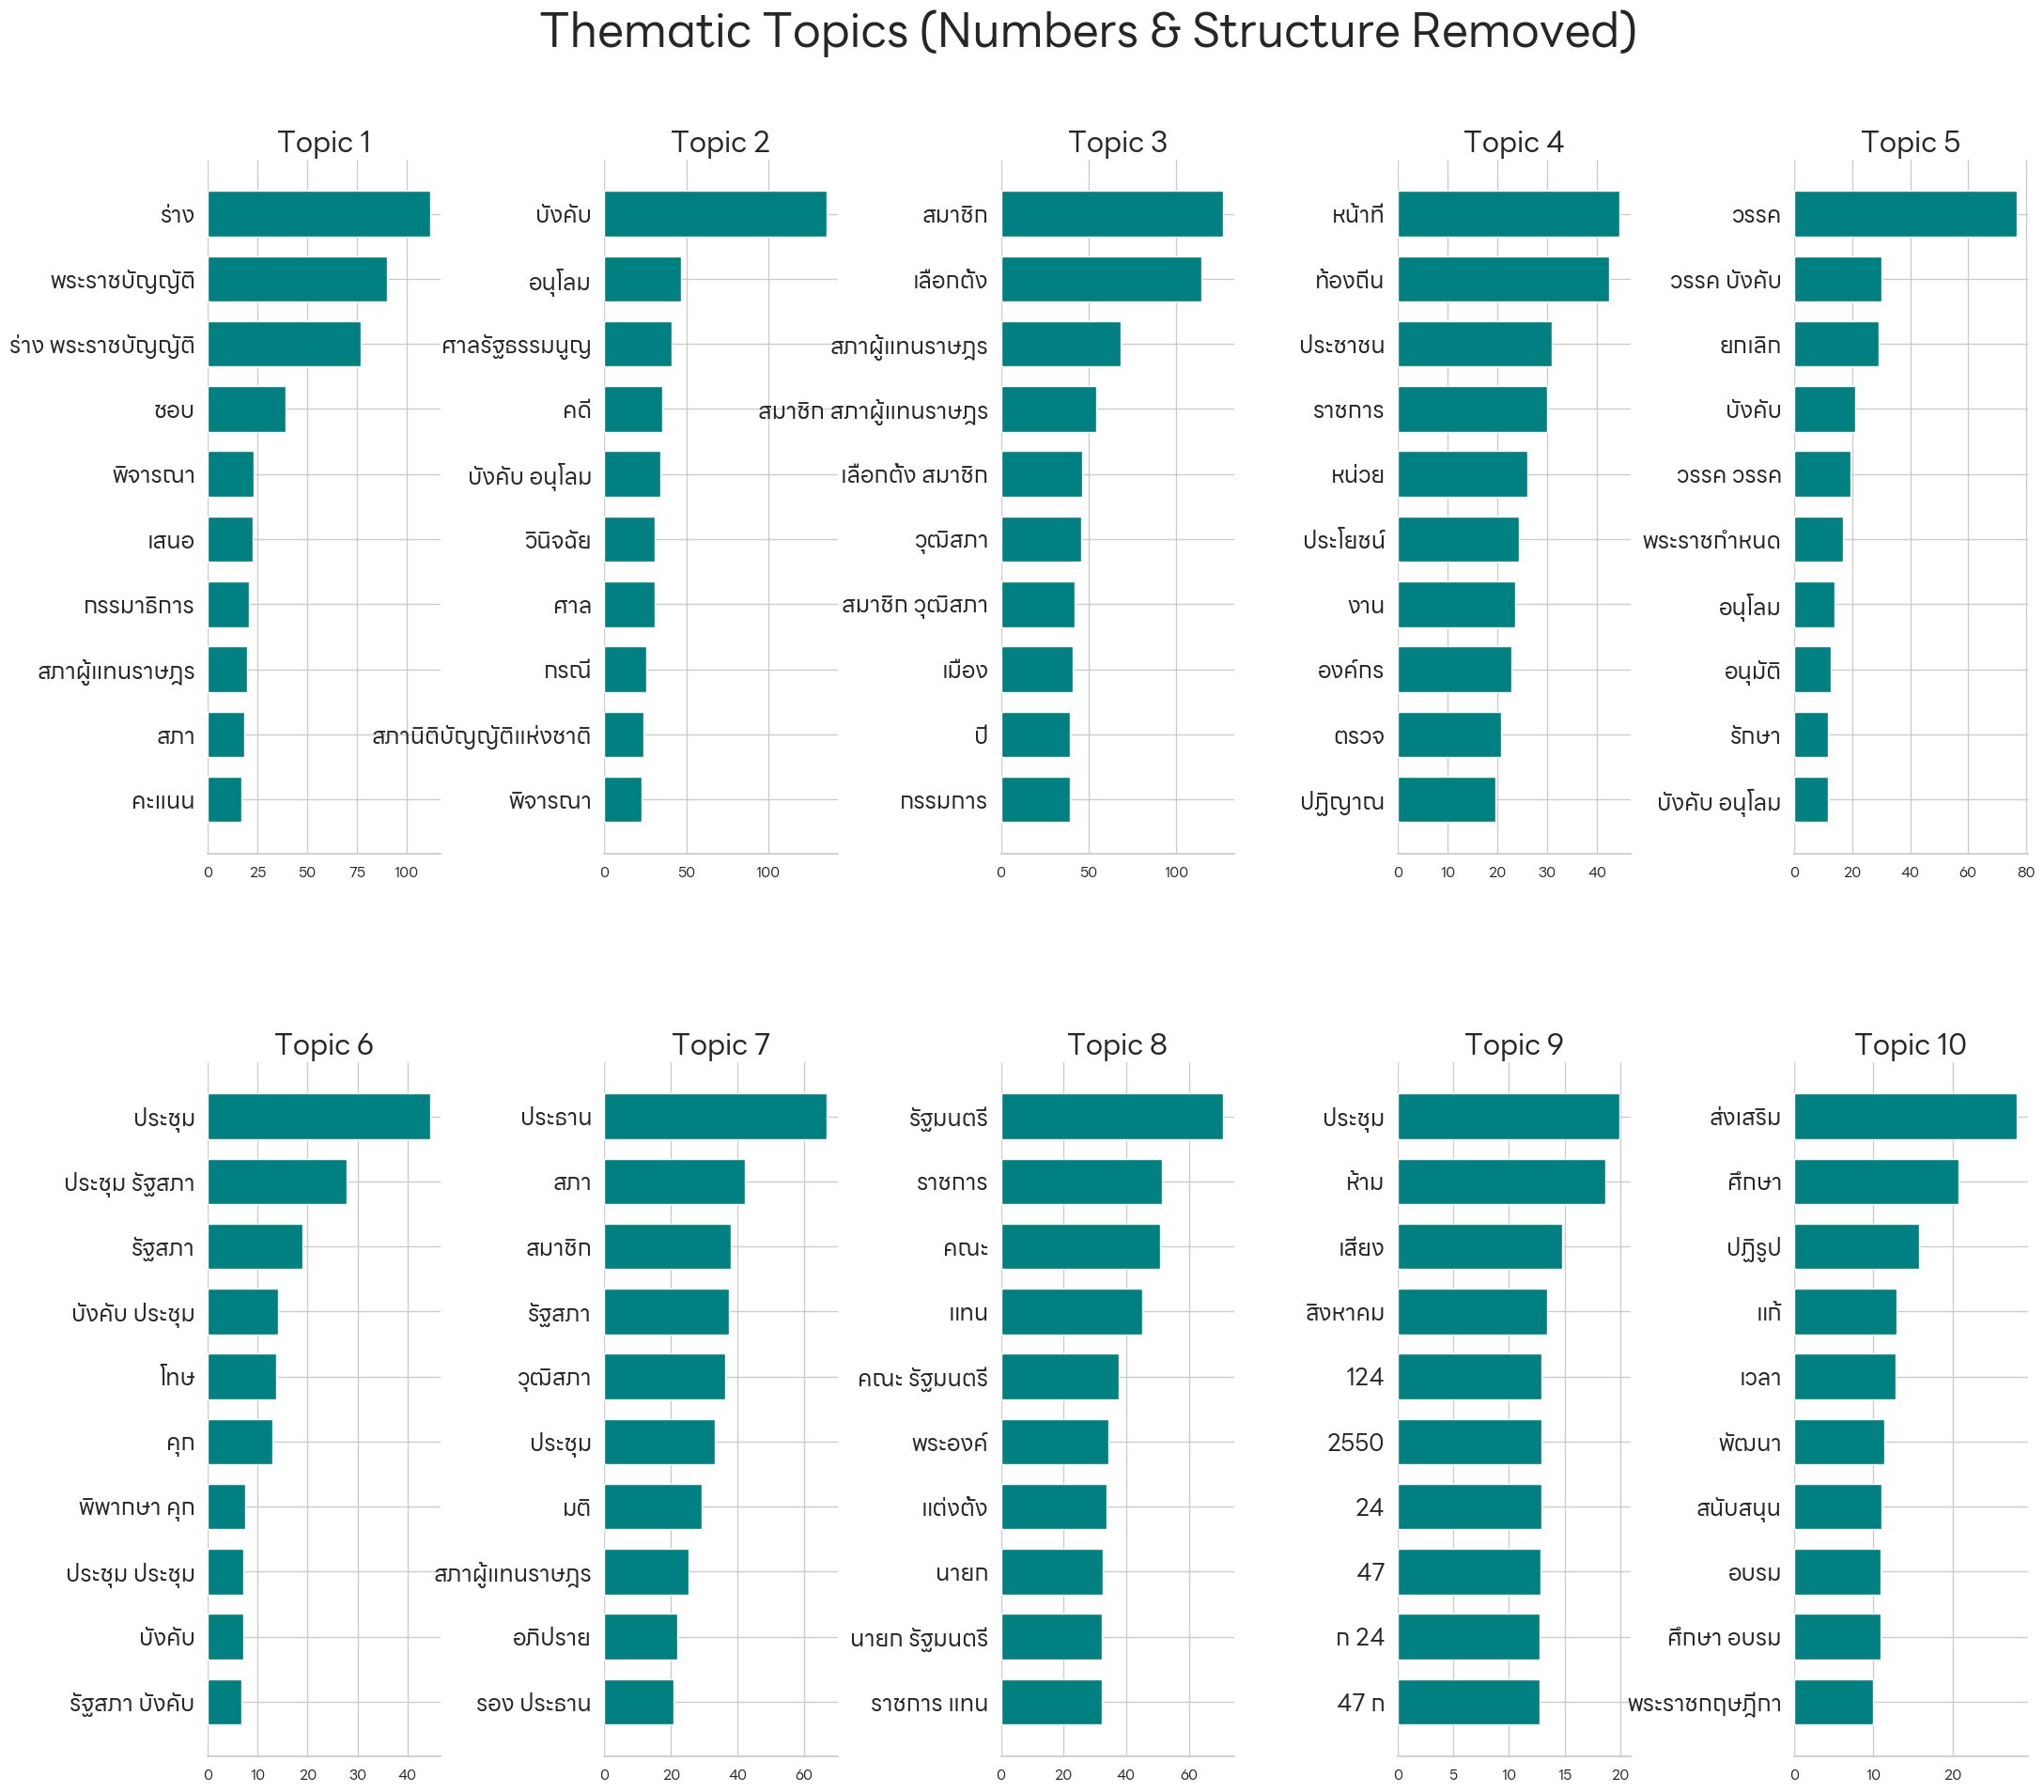

In [99]:
def plot_top_words_clean(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(2, 5, figsize=(25, 20), sharex=False)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7, color='teal')
        ax.set_title(f"Topic {topic_idx + 1}", fontproperties=font_prop, fontsize=22)
        ax.set_yticklabels(top_features, fontproperties=font_prop, fontsize=18)
        ax.invert_yaxis()
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
            
    fig.suptitle(title, fontproperties=font_prop, fontsize=36)
    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.7, hspace=0.3)
    plt.show()

feature_names = vectorizer.get_feature_names_out()
plot_top_words_clean(lda, feature_names, 10, "Thematic Topics (Numbers & Structure Removed)")

## 5. Topic Distribution Over Time

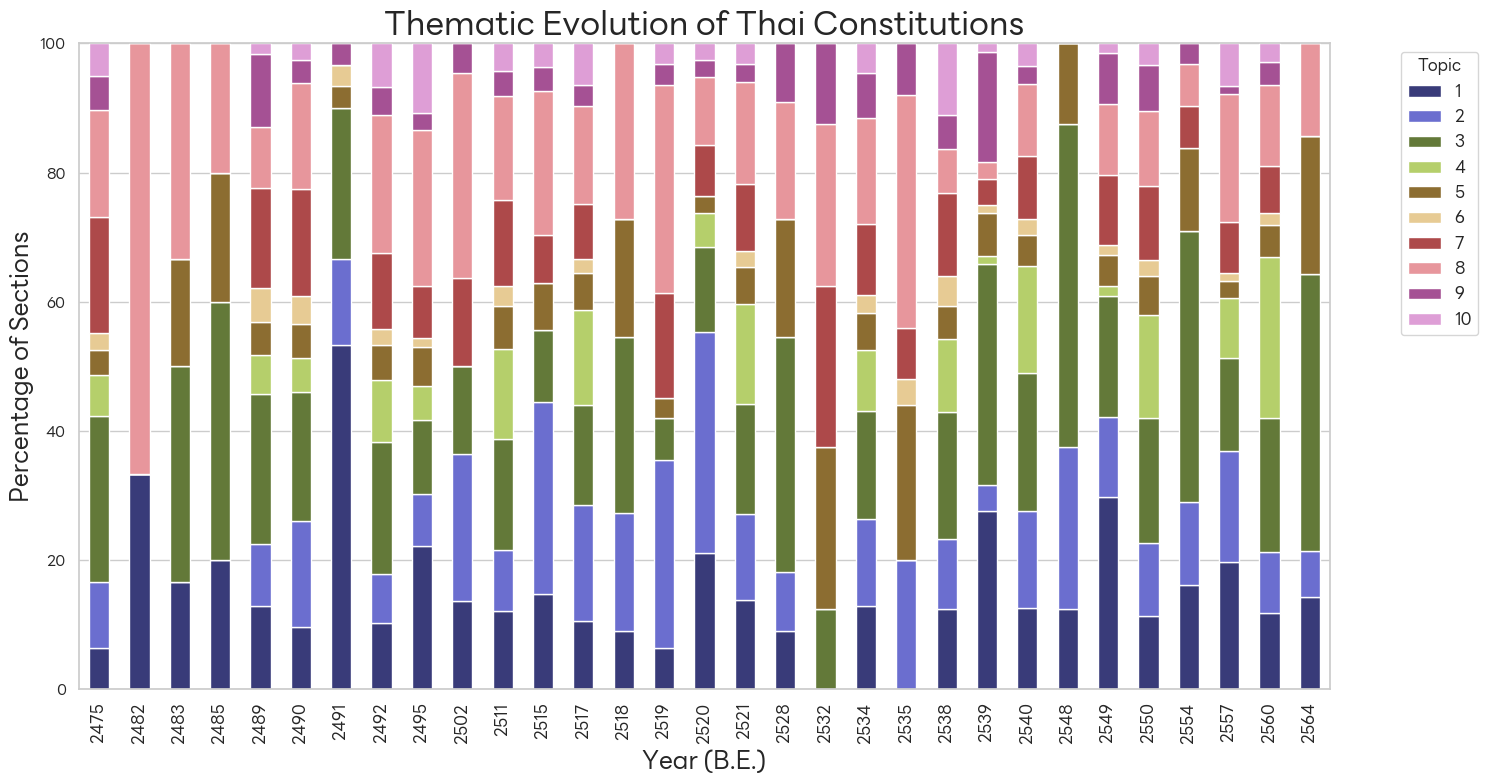

In [100]:
df['dominant_topic'] = np.argmax(lda_output, axis=1) + 1
topic_over_time = df.groupby(['year_th', 'dominant_topic']).size().unstack(fill_value=0)
topic_over_time_pct = topic_over_time.div(topic_over_time.sum(axis=1), axis=0) * 100

plt.figure(figsize=(15, 8))
ax = topic_over_time_pct.plot(kind='bar', stacked=True, colormap='tab20b', ax=plt.gca())
plt.title("Thematic Evolution of Thai Constitutions", fontproperties=font_prop, fontsize=24)
plt.xlabel("Year (B.E.)", fontproperties=font_prop, fontsize=18)
plt.ylabel("Percentage of Sections", fontproperties=font_prop, fontsize=18)
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc='upper left', prop=font_prop)
plt.xticks(fontproperties=font_prop)
plt.tight_layout()
plt.show()